In [1]:
from collections import defaultdict
from pathlib import Path

import colorcet as cc
import equinox as eqx
import h5py
import jax
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from context_flux_no.metrics import relative_L2_error, relative_L_infty_error
from context_flux_no.plotting.lineplots import plot_mean_and_std
from context_flux_no.training.io import load_model
from einops import rearrange
from tqdm import tqdm


plt.style.use("context_flux_no.plotting.styles.dash_gridded")

COLOR_DICT = {
    "DPOT": cc.cm.glasbey_bw(85),
    "ICON": cc.cm.glasbey_bw(1),
    "DISCO": cc.cm.glasbey_bw(68),
    "HyperFluxFNOLocal": cc.cm.glasbey_bw(41),
}

LABEL_DICT = {
    "DPOT": "DPOT",
    "ICON": "ICON",
    "DISCO": "DISCO",
    "HyperFluxFNOLocal": "HFluxNO (Ours)",
}
datadir = Path("../../data")
checkpoint_dir = Path("../../checkpoints")

jax.config.update("jax_default_device", jax.devices("gpu")[0])

In [2]:
model_paths = {
    "DPOT": [
        "seed=0/26-04-10-14:49:05",
        "seed=10/26-04-16-18:37:37",
        "seed=20/26-04-17-07:57:49",
    ],
    "HyperFluxFNOLocal": [
        "seed=0/26-04-16-00:31:47",
        "seed=10/26-04-17-07:57:49",
        "seed=20/26-04-17-10:50:08",
    ],
    "DISCO": [
        "seed=0/26-04-10-21:26:22",
        "seed=10/26-04-16-18:37:50",
        "seed=20/26-04-16-18:37:50",
    ],
}

In [3]:
dataset_test = (
    xr.open_dataset(
        datadir
        / "datasets/cubic_no_source/data/test/cubic_no_source_large_test_seed=10.hdf5",
        engine="h5netcdf",
        chunks={},
    ).isel(t=slice(None, None, 10))
    # .isel({"t": slice(0, 99)})
)
dt = float(dataset_test["t"][1] - dataset_test["t"][0])
dx = float(dataset_test["x"][1] - dataset_test["x"][0])

values = rearrange(dataset_test["values"].values, "pde ic ... -> (pde ic) ...")

## Compute rolled out trajectories for seed=0, and for a fixed trajectory

In [4]:
u_pred_dict = {}

traj_idx = 0
for model_type, paths in model_paths.items():
    model = load_model(checkpoint_dir / model_type / "OneStepLoss" / paths[0])
    model = eqx.nn.inference_mode(model, True)

    context, u_data = values[traj_idx, :20], values[traj_idx, 20:]
    u_pred = model.rollout(context, (dt, dx), num_steps=len(u_data))[0]

    u_pred_dict[model_type] = u_pred

/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/models/multiphysics/hyperfluxfno/encoders/utils.py:50: UserWarning: TRecViTEncoder supports variable in_timesteps. The given 
                    in_timesteps value will be ignored.
  warnings.warn(
/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/nn/structured_linear.py:40: UserWarning: out_features is not divisible by num_blocks. Output vector 
            will be truncated to the requested size.
  warnings.warn("""out_features is not divisible by num_blocks. Output vector
E0504 20:09:22.157368  905586 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.10 = f32[128,500]{1,0} fusion(get-tuple-element.93, bitcast.1110), kind=kCustom, calls=gemm_fusion_dot.10_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"8","output_tiles":[{"sizes":["128","256"]}],"num_ctas":1,"num_stages":4,"i

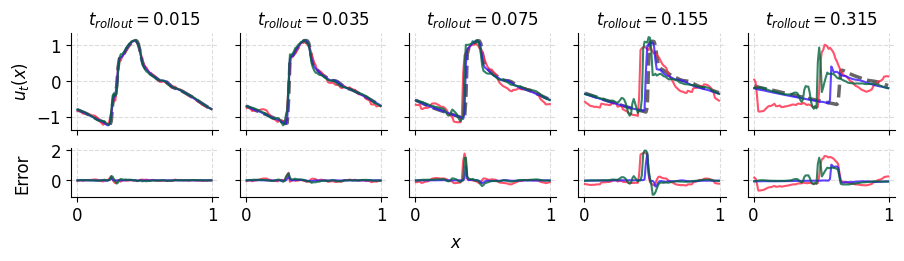

In [5]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(9, 2.5),
    constrained_layout=True,
    sharex=True,
    sharey="row",
    height_ratios=(2, 1),
)
for i in range(axes.shape[1]):
    t_idx = 4 * 2**i - 1
    axes[0, i].plot(
        dataset_test.x,
        u_data[t_idx, 0],
        label="Data",
        color="black",
        linewidth=2.5,
        ls="--",
        alpha=0.6,
    )
    for model_type, u_pred in u_pred_dict.items():
        axes[0, i].plot(
            dataset_test.x,
            u_pred[t_idx, 0],
            label=LABEL_DICT[model_type],
            color=COLOR_DICT[model_type],
            linewidth=1.5,
            alpha=0.8,
        )
        axes[1, i].plot(
            dataset_test.x,
            u_pred[t_idx, 0] - u_data[t_idx, 0],
            label=LABEL_DICT[model_type],
            color=COLOR_DICT[model_type],
            linewidth=1.5,
            alpha=0.8,
        )
        axes[0, i].set_title("$t_{rollout}=$" + f"${t_idx * dt}$", fontsize="medium")
        # axes[0, i].text(0.4, -1.2, )
fig.supxlabel("$x$", fontsize="medium")
axes[0, 0].set_ylabel("$u_t(x)$")
axes[1, 0].set_ylabel("Error")
fig.align_ylabels()
fig.savefig("../../figures/fig2/rollout_trajectory_cubic_id.pdf", dpi=500)

In [6]:
dataset_test = (
    xr.open_dataset(
        datadir / "datasets/cubic_no_source/data/test/sine_1d_test_step_seed=12.hdf5",
        engine="h5netcdf",
        chunks={},
    ).isel(t=slice(None, None, 10))
    # .isel({"t": slice(0, 99)})
)
dt = float(dataset_test["t"][1] - dataset_test["t"][0])
dx = float(dataset_test["x"][1] - dataset_test["x"][0])

values = rearrange(dataset_test["values"].values, "pde ic ... -> (pde ic) ...")

In [7]:
u_pred_dict = {}

traj_idx = 0
for model_type, paths in model_paths.items():
    model = load_model(checkpoint_dir / model_type / "OneStepLoss" / paths[0])
    model = eqx.nn.inference_mode(model, True)

    context, u_data = values[traj_idx, :20], values[traj_idx, 20:]
    u_pred = model.rollout(context, (dt, dx), num_steps=len(u_data))[0]

    u_pred_dict[model_type] = u_pred

/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/models/multiphysics/hyperfluxfno/encoders/utils.py:50: UserWarning: TRecViTEncoder supports variable in_timesteps. The given 
                    in_timesteps value will be ignored.
  warnings.warn(
/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/nn/structured_linear.py:40: UserWarning: out_features is not divisible by num_blocks. Output vector 
            will be truncated to the requested size.
  warnings.warn("""out_features is not divisible by num_blocks. Output vector
/home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1269: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


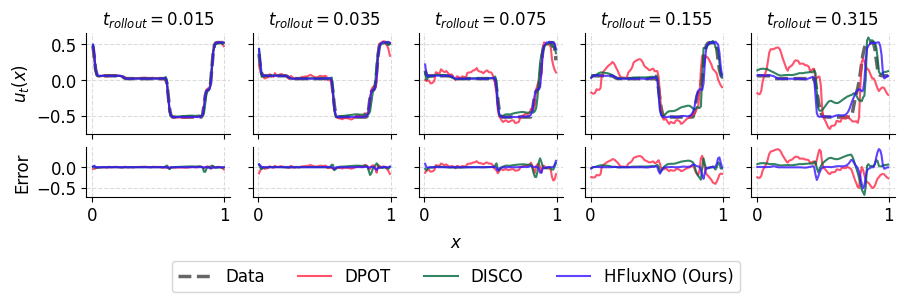

In [30]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(9, 2.5),
    constrained_layout=True,
    sharex=True,
    sharey="row",
    height_ratios=(2, 1),
)
for i in range(axes.shape[1]):
    t_idx = 4 * 2**i - 1
    axes[0, i].plot(
        dataset_test.x,
        u_data[t_idx, 0],
        label="Data",
        color="black",
        linewidth=2.5,
        ls="--",
        alpha=0.6,
    )
    for model_type in ("DPOT", "DISCO", "HyperFluxFNOLocal"):
        u_pred = u_pred_dict[model_type]
        axes[0, i].plot(
            dataset_test.x,
            u_pred[t_idx, 0],
            label=LABEL_DICT[model_type],
            color=COLOR_DICT[model_type],
            linewidth=1.5,
            alpha=0.8,
        )
        axes[1, i].plot(
            dataset_test.x,
            u_pred[t_idx, 0] - u_data[t_idx, 0],
            label=LABEL_DICT[model_type],
            color=COLOR_DICT[model_type],
            linewidth=1.5,
            alpha=0.8,
        )
        axes[0, i].set_title("$t_{rollout}=$" + f"${t_idx * dt}$", fontsize="medium")
        # axes[0, i].text(0.4, -1.2, )

axes[0, 0].set_ylabel("$u_t(x)$")
axes[1, 0].set_ylabel("Error")
fig.align_ylabels()
fig.legend(
    *axes[0, 0].get_legend_handles_labels(),
    loc="outside lower center",
    ncols=4,
    bbox_to_anchor=(0.5, -0.18),
)
fig.supxlabel("$x$", fontsize="medium")
fig.savefig(
    "../../figures/fig2/rollout_trajectory_cubic_ood_sine_step.pdf",
    dpi=500,
    bbox_inches="tight",
)

## Compute and save long rollout error metrics

In [4]:
@eqx.filter_jit
def metrics_long_rollout(model, u, args, context_length=20):
    context, u_data = u[:context_length], u[context_length:]
    u_pred = model.rollout(context, args, num_steps=len(u_data))[0]
    l2 = jax.vmap(relative_L2_error)(u_pred, u_data)
    l_inf = jax.vmap(relative_L_infty_error)(u_pred, u_data)
    return {"l2": l2, "l_inf": l_inf}

In [5]:
results_dict = defaultdict(list)
for model_type, paths in model_paths.items():
    for p in tqdm(paths):
        model = load_model(checkpoint_dir / model_type / "OneStepLoss" / p)
        model = eqx.nn.inference_mode(model, True)
        results = jax.lax.map(
            eqx.filter_jit(lambda u: metrics_long_rollout(model, u, (dt, dx))),
            values,
            batch_size=2000,
        )
        print(jax.tree.map(lambda x: x.shape, results))
        results_dict[model_type].append(results)


 33%|███▎      | 1/3 [00:45<01:30, 45.02s/it]

{'l2': (10000, 79), 'l_inf': (10000, 79)}


 67%|██████▋   | 2/3 [01:00<00:27, 27.65s/it]

{'l2': (10000, 79), 'l_inf': (10000, 79)}


100%|██████████| 3/3 [01:19<00:00, 26.38s/it]


...

{'l2': (10000, 79), 'l_inf': (10000, 79)}


 67%|██████▋   | 2/3 [06:56<03:23, 204.00s/it]

{'l2': (10000, 79), 'l_inf': (10000, 79)}


100%|██████████| 3/3 [10:25<00:00, 208.62s/it]

{'l2': (10000, 79), 'l_inf': (10000, 79)}


In [10]:
results_stacked = {
    k: jax.tree.transpose(
        jax.tree.structure(["*"] * 3),
        None,
        v,
    )
    for k, v in results_dict.items()
}
results_stacked = jax.tree.map(
    np.stack, results_stacked, is_leaf=lambda x: isinstance(x, list)
)

In [12]:
jax.tree.map(lambda x: x.shape, results_stacked)

{'DISCO': {'l2': (3, 10000, 79), 'l_inf': (3, 10000, 79)},
 'DPOT': {'l2': (3, 10000, 79), 'l_inf': (3, 10000, 79)},
 'HyperFluxFNOLocal': {'l2': (3, 10000, 79), 'l_inf': (3, 10000, 79)}}

In [ ]:
with h5py.File("../../data/analysis/cubic_1d_long_rollout.hdf5", "w") as f:
    for model_name, res_dict in results_stacked.items():
        g = f.create_group(model_name)
        for metric_name, val in res_dict.items():
            g.create_dataset(metric_name, data=val)

## Load and plot long time rollout metrics

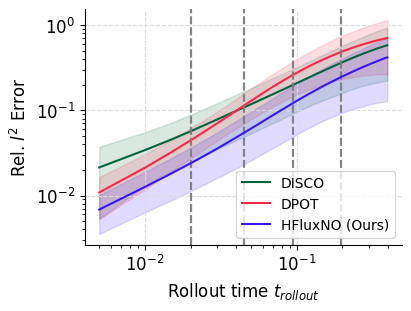

In [86]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3), constrained_layout=True, sharex=True)

with h5py.File("../../data/analysis/cubic_1d_long_rollout.hdf5", "r") as f:
    for model_type, res in f.items():
        for i in range(4):
            ax.axvline(x=(5 * 2**i - 1) * dt, ls="--", color="gray", alpha=0.7)
        l2 = res["l2"][0]
        ax = plot_mean_and_std(
            ax,
            np.arange(1, l2.shape[1] + 1) * dt,
            l2,
            color=COLOR_DICT[model_type],
            label=LABEL_DICT[model_type],
            alpha_band=0.15,
        )


ax.set_yscale("log")
ax.set_xscale("log")
ax.set_xlabel("Rollout time $t_{rollout}$")
ax.set_ylabel("Rel. $l^2$ Error")
ax.legend(fontsize="small", loc="lower right")
fig.savefig("../../figures/fig2/rollout_l2.pdf", dpi=500)